# Problem Set 1 — ¿Qué distingue a un género musical?

**S100 · Introducción a la Ciencia de Datos** · Maestría en Analítica de Datos, UTP
**Prof. Gabriel Soto, M.Sc.** · II Semestre 2026

**Modalidad:** individual · **Datos:** `spotify_songs.csv` (32,833 canciones)

---

## El caso

Una plataforma de streaming quiere entender **en qué se diferencian los géneros musicales**
según las características de audio de sus canciones. Te pasan la tabla completa y cinco
preguntas que van de lo general a lo específico.

Los cinco ejercicios están **encadenados**: cada uno usa resultados del anterior. Resuélvelos
en orden y no borres las variables que vayas creando.

---

## Instrucciones de entrega

**1 · Trabaja sobre este cuaderno.** Escribe tu código en las celdas marcadas y tus respuestas
escritas en las celdas de texto que dicen *Tu respuesta*. El cuaderno debe **correr de principio
a fin sin errores** (Kernel → Restart & Run All antes de entregar).

**2 · Sube el cuaderno a tu repositorio de GitHub.**

- Crea (o usa) un repositorio para el curso, por ejemplo `S100-analitica-datos`.
- Súbelo con el nombre `S100_PS1_TuApellido.ipynb`.
- El repositorio debe ser **público** (o darme acceso). Si no puedo abrirlo, no puedo calificarlo.
- El historial de commits debe mostrar tu trabajo: haz varios commits, no uno solo al final.

**3 · Envía por correo ÚNICAMENTE el enlace a GitHub.**

- Correo: **gabriel.soto@utp.ac.pa**
- Asunto: `S100 - Problem Set 1 - TuNombre`
- En el cuerpo va **solo el enlace** al repositorio (o al cuaderno dentro del repositorio).
- **No adjuntes archivos.** Los correos con el cuaderno adjunto y sin enlace no se califican.

**4 · Registra tu enlace en la lista del curso.**

- Abre el archivo **`S100 Lista Estudiantes Provisional`**, ubicado en el **SharePoint del curso**,
  carpeta **`01_administracion`**.
- Agrega el enlace de tu repositorio de GitHub **en la fila que corresponde a tu nombre**.
- Este paso es parte de la entrega: sin el enlace en la lista, la entrega se considera incompleta.

> **Sobre el uso de IA.** Está permitido, con una condición: que puedas explicar lo que
> entregaste. En la última celda del cuaderno indica en qué ejercicios la usaste y qué hace ese
> código. No hay penalización por usarla; sí la hay por entregar código que no sabes leer.

## Calificación

| Ejercicio | Qué se evalúa | Puntos |
|---|---|---|
| 1 | Exploración inicial correcta y completa | 15 |
| 2 | Resumen numérico + histograma bien etiquetado | 15 |
| 3 | Comparación por género + gráfico que se entiende solo | 20 |
| 4 | Matriz de correlación, identificación de pares, interpretación | 25 |
| 5 | Correlación por grupo, estandarización y conclusión escrita | 25 |

Los gráficos sin **título** y sin **etiquetas de eje con unidad** pierden puntos, siempre.


---
## Paso 0 · Preparación

Ejecuta esta celda. No hay que escribir nada aquí.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

df = pd.read_csv("spotify_songs.csv")

# La duración viene en milisegundos: la pasamos a minutos, que sí se puede interpretar.
df["duration_min"] = df["duration_ms"] / 60000

# Las 10 variables de audio con las que vamos a trabajar todo el problem set.
audio = ["danceability", "energy", "loudness", "speechiness", "acousticness",
         "instrumentalness", "liveness", "valence", "tempo", "duration_min"]

print("Filas y columnas:", df.shape)

Filas y columnas: (32833, 24)


### Diccionario de las columnas que vas a usar

| Columna | Qué es |
|---|---|
| `track_name`, `track_artist` | Nombre de la canción y del artista |
| `track_popularity` | Popularidad de 0 a 100 |
| `playlist_genre` | Género: pop, rap, rock, latin, r&b, edm |
| `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness`, `speechiness` | Índices de 0 a 1 |
| `loudness` | Volumen medio en decibeles (negativo) |
| `tempo` | Pulsos por minuto (BPM) |
| `duration_min` | Duración en minutos (la creamos arriba) |


---
# Ejercicio 1 · Conocer los datos antes de calcular nada
**Dificultad: baja** · 15 puntos

Antes de responder cualquier pregunta hay que saber qué hay en la tabla. Haz estas cuatro cosas:

**a)** Muestra las **primeras filas** de `df`.

**b)** Saca el **resumen estadístico** de las columnas numéricas.

**c)** Cuenta **cuántas canciones hay de cada género** (`playlist_genre`).

**d)** Cuenta **cuántos valores faltan** en cada columna.

> 💡 **Pistas.** `df.head()` · `df.describe()` · `df["columna"].value_counts()` · `df.isna().sum()`
> Para ver solo las columnas donde sí falta algo: guarda el resultado en una variable `faltan` y
> filtra con `faltan[faltan > 0]`.

In [2]:
# a) Primeras filas
print('\n a) PRIMERAS FILAS=====================')
print(df.head(3))

# b) Resumen estadístico
print('\n b) RESUMEN ESTADISTICO====================\n',df.describe())

# c) Canciones por género
print('\n c) CANCIONES POR GENERO====================\n',df.groupby('playlist_genre')['track_id'].count().sort_values())
# df["playlist_genre"].value_counts()

# d) Valores faltantes
print('\n d) VALORES FALTANTES=====================')
df.isna().sum()




 a) PRIMERAS FILAS=====================
                 track_id                                         track_name   
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...  \
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   

   track_artist  track_popularity          track_album_id   
0    Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx  \
1      Maroon 5                67  63rPSO264uRjW1X5E6cWv6   
2  Zara Larsson                70  1HoSmj2eLcsrR0vE9gThr4   

                                    track_album_name track_album_release_date   
0  I Don't Care (with Justin Bieber) [Loud Luxury...               2019-06-14  \
1                    Memories (Dillon Francis Remix)               2019-12-13   
2                    All the Time (Don Diablo Remix)               2019-07-05   

  playlist_name             playlist_id playlist_genre  ... loudness

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
duration_min                0
dtype: int64

### 📝 Tu respuesta — Ejercicio 1

**1.** ¿Los seis géneros tienen más o menos la misma cantidad de canciones, o hay alguno
   muy por encima o por debajo? ¿Por qué importa eso antes de comparar promedios entre géneros?

> podria decirse que estan cerca unos de otros edm muy por encima de rock, pero entre ellos tienen una diferencia mas o menos de 100 a 300 canciones, es importante porque pueden tener dificultades si sus extremos estan muy dispersos uno de otro lo que podriamos estar evaluando serian valores anormales, lo que podria generar daños en la precision del modelo.

**2.** Mira la fila `min` y la fila `max` de `duration_min` en el `describe()`. ¿Hay algún valor
   que te haga sospechar de un error de captura? Explica en una frase.

>la diferencia es abismal, es un error de captura definitivamente una cancion de 0.06 minutos por lo general las canciones rondan los 3 minutos y muy pocas de 8 minutos pero si pueden existir e 8 min en especial en versiones extendidas donde comparten saludos o son raps dedicados a otros artistas.

---
# Ejercicio 2 · Resumir una variable
**Dificultad: baja** · 15 puntos

Del Ejercicio 1 ya sabes qué contiene la tabla. Ahora nos concentramos en **una sola variable:
`energy`**, que va a ser el hilo conductor del resto del problem set.

**a)** Calcula de `energy`: **media**, **mediana**, **desviación estándar** y **rango**
(el rango es el máximo menos el mínimo).

**b)** Haz un **histograma** de `energy` con 30 barras. Debe llevar **título** y **etiquetas de eje**.

**c)** Calcula el `skew()` de `energy`.

> 💡 **Pistas.** Los resúmenes son métodos: `df["energy"].mean()`, `.median()`, `.std()`,
> `.max()`, `.min()`, `.skew()`.
> Para el histograma: `plt.hist(df["energy"], bins=30, color=AZUL, edgecolor="white")` y luego
> `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`, `plt.show()`.
> Recuerda: skew cerca de 0 = simétrica; positivo = cola a la derecha; negativo = cola a la izquierda.

a) Media, mediana, desviación estándar y rango de energy: 
Media: 0.6986192707032558 Mediana: 0.721
Var. Estandar: 0.18091003391959107 Maximo: 1.0
Rango (maximo menos el minimo): 0.999825
Minimo: 0.000175 

b) histograma: 


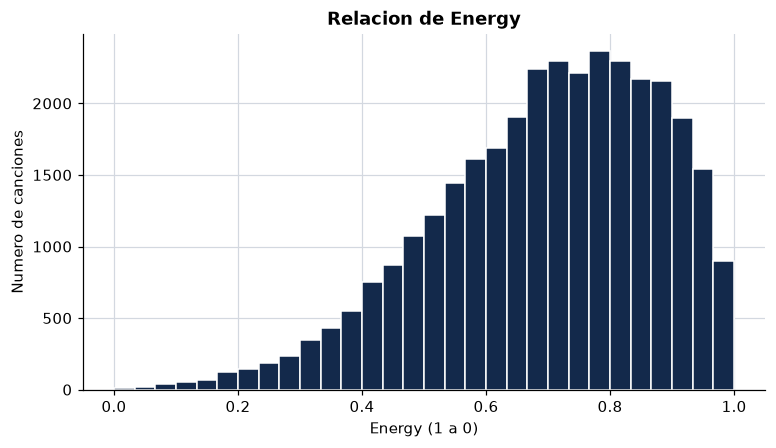

c) que tan simetrico o asimetrico es:  -0.6363298409581105


In [3]:
# # a) Media, mediana, desviación estándar y rango de energy
print("a) Media, mediana, desviación estándar y rango de energy: ")
print(f"Media: {df['energy'].mean()} Mediana: {df['energy'].median()}")
print(f"Var. Estandar: {df['energy'].std()} Maximo: {df['energy'].max()}")
print(f"Rango (maximo menos el minimo): {df['energy'].max()-df['energy'].min()}")
print(f"Minimo: {df['energy'].min()} ")


# b) Histograma
print("\nb) histograma: ")
x, y, z =  plt.hist(df["energy"],bins=30,  color=AZUL, edgecolor="white")
#x = cantidades, y= limites o rangos(bins) , z= barras fisicas.
#plt.bar_label(z,label_type="center",rotation=90,color="white")
plt.xlabel('Energy (1 a 0)')
plt.ylabel('Numero de canciones')
plt.title('Relacion de Energy')
plt.show()

# c) Asimetría
print(f"c) que tan simetrico o asimetrico es:  {df['energy'].skew()}")


### 📝 Tu respuesta — Ejercicio 2

**1.** Escribe los cuatro números de (a) en una frase.

> La media 0.698, con la mediana en 0.721, desviacion estandar en 0.18 y el rango de energy en 0.99 lo que nos indica que los datos de energy tienen muy poca dispersion.

**2.** ¿La media quedó por encima o por debajo de la mediana? ¿Hacia qué lado está la cola?
   ¿Coincide eso con el signo del `skew()` y con lo que ves en el histograma?

> la media quedo ligeramente por debajo de la mediana, 0.699 y 0.721 respectivamente. mirando el valor de skew el cual es negativo nos muestra que coincide con los calculos de la media y mediana que indican una asimentria negativa ( cola hacia la izquierda), esto se evidencia en el histograma donde la mayoria de las canciones son energicas pero existen valores muy bajos que mueven la distribucion a la izquierda.

---
# Ejercicio 3 · ¿En qué se diferencian los géneros?
**Dificultad: baja** · 20 puntos

Ya sabes cómo se reparte `energy` en toda la tabla. La pregunta ahora es si **esa repartición es
la misma dentro de cada género**.

**a)** Calcula la **media** y la **desviación estándar** de `energy` **por género**, en una sola tabla.
Ordénala de mayor a menor por la media y guárdala en una variable llamada `energia_genero`
(la vas a volver a usar en el Ejercicio 5).

**b)** Haz un **gráfico de barras horizontales** con la media de `energy` por género.
Ordenado por valor, con título y etiqueta de eje.

**c)** Haz un **boxplot** de `energy` por género.

> 💡 **Pistas.**
> `df.groupby("playlist_genre")["energy"].agg(["mean", "std"])` da las dos columnas de una vez;
> después `.sort_values("mean", ascending=False)`.
> Barras horizontales: `plt.barh(serie.index, serie.values, color=AZUL)` — ordena la serie de
> **menor a mayor** para que la barra más larga quede arriba.
> Boxplot: `df.boxplot(column="energy", by="playlist_genre")`, o armando la lista de grupos
> como hicimos en el laboratorio de la Clase 3.
>
> ⚠️ "Más enérgico" y "más disperso" son preguntas distintas: la primera la contesta la media,
> la segunda la desviación estándar. No asumas que van juntas.

                    mean       std
playlist_genre                    
edm             0.802476  0.139415
rock            0.732813  0.194501
latin           0.708312  0.152308
pop             0.701028  0.171084
rap             0.650708  0.170340
r&b             0.590934  0.179407


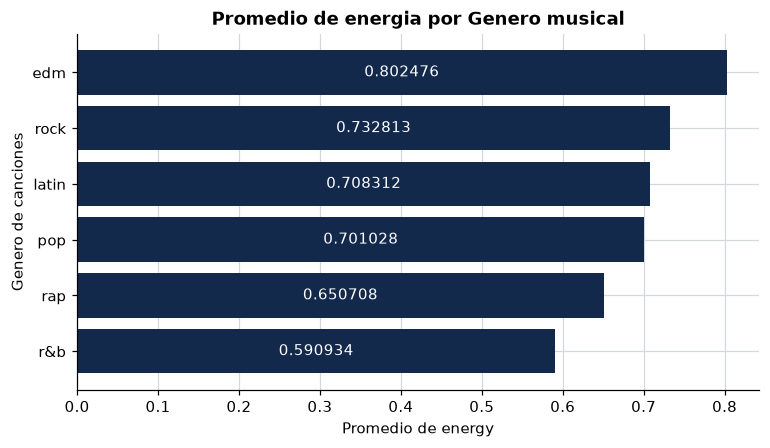

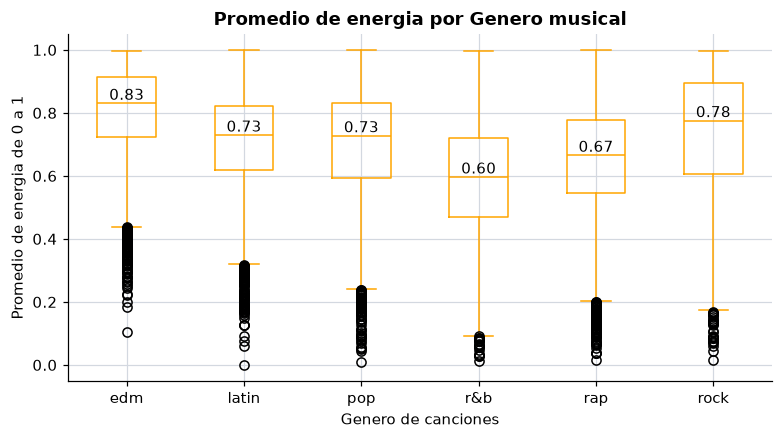

In [4]:
# a) Media y desviación de energy por género
energia_genero = df.groupby("playlist_genre")["energy"].agg(["mean","std"])
#print(df.groupby("playlist_genre")["energy"].sum(),'\n')
print(energia_genero.sort_values("mean", ascending=False))


# b) Gráfico de barras horizontales
serie = energia_genero["mean"].sort_values()
barras = plt.barh(serie.index,serie.values, color= AZUL)
plt.bar_label(barras,label_type="center",color="white")
plt.xlabel('Promedio de energy')
plt.ylabel('Genero de canciones')
plt.title('Promedio de energia por Genero musical')
plt.show()

# c) Boxplot
# energia_genero.boxplot()
df.boxplot(column="energy",by="playlist_genre",color="orange")
mediana = df.groupby("playlist_genre")["energy"].agg("median")

for i, valor in enumerate(mediana):
    plt.text(i + 1, valor, f"{valor:.2f}",
             ha="center", va="bottom")
    
plt.xlabel('Genero de canciones')
plt.ylabel('Promedio de energia de 0 a 1')
plt.suptitle('')
plt.title('Promedio de energia por Genero musical')
plt.show()

### 📝 Tu respuesta — Ejercicio 3

**1.** ¿Cuál es el género **más enérgico** en promedio y cuál el **menos**? Da los dos números.

> segun la grafica y los datos el mas energico es edm con un valor de 0.80 y el menos energico es r&b con un valor de 0.59

**2.** ¿Cuál es el género **más disperso** (mayor desviación estándar)? ¿Es el mismo que el más
   enérgico? ¿Qué significa, en palabras, que un género tenga mucha dispersión en `energy`?

> el género mas disperso es el de rock con un valor de 0.194, no es el mismo que el mas energico ya que para ser considerado el más enérgico debe contar con una desviación estándar menor, es decir, ser más constante. Que un género tenga mucha dispersión en energy significa que tiene canciones con un nivel de energia muy alto y otras con un nivel muy bajo con respecto a la media, lo que podría afectar la simetría

**3.** Tapa el código y mira solo tu gráfico de barras. ¿Lo pondrías en un informe sin escribir
   un párrafo explicándolo? Si no, arréglalo antes de seguir.

>Listo

---
# Ejercicio 4 · Buscar relaciones entre variables
**Dificultad: media** · 25 puntos

Hasta aquí miraste variables **una por una**. Ahora las miramos **de a dos**: ¿cuáles se mueven
juntas?

**a)** Calcula la **matriz de correlación** de las 10 variables de la lista `audio`.

**b)** Conviértela en una lista ordenada de pares y encuentra el par **más positivo** y el
**más negativo**. Ojo con dos cosas antes de ordenar:
- la **diagonal** (toda variable correlaciona 1 consigo misma) hay que quitarla;
- la matriz es **simétrica**, así que cada par aparece dos veces: quédate con una sola copia.
Si lo haces bien, tu lista debe tener **45 pares**, no 90.

**c)** Grafica el par **más positivo** con un diagrama de dispersión.
Con 32,833 puntos la nube se vuelve una mancha: usa una muestra y transparencia.

**d)** Calcula ahora la correlación de cada variable de `audio` con `track_popularity`.
¿Cuál es la que más se relaciona con la popularidad?

> 💡 **Pistas.**
> `corr = df[audio].corr()`
> ```python
> pares = corr.unstack()
> pares = pares[pares < 0.999]                                       # fuera la diagonal
> pares = pares[pares.index.get_level_values(0) < pares.index.get_level_values(1)]  # fuera repetidos
> pares = pares.sort_values()
> ```
> El primero y el último de esa lista son los que buscas.
> Para el gráfico: `m = df.sample(4000, random_state=1)` y luego
> `plt.scatter(m["x"], m["y"], s=6, alpha=0.25, color=AZUL, lw=0)`.
> Para (d): `df[audio + ["track_popularity"]].corr()["track_popularity"].sort_values()`.

a) matriz de correlacion: 
                   danceability    energy  loudness  speechiness  acousticness   
danceability          1.000000 -0.086073  0.025335     0.181721     -0.024519  \
energy               -0.086073  1.000000  0.676625    -0.032150     -0.539745   
loudness              0.025335  0.676625  1.000000     0.010339     -0.361638   
speechiness           0.181721 -0.032150  0.010339     1.000000      0.026092   
acousticness         -0.024519 -0.539745 -0.361638     0.026092      1.000000   
instrumentalness     -0.008655  0.033247 -0.147824    -0.103424     -0.006850   
liveness             -0.123859  0.161223  0.077613     0.055426     -0.077243   
valence               0.330523  0.151103  0.053384     0.064659     -0.016845   
tempo                -0.184084  0.149951  0.093767     0.044603     -0.112724   
duration_min         -0.096879  0.012611 -0.115058    -0.089431     -0.081581   

                  instrumentalness  liveness   valence     tempo  duration_min  

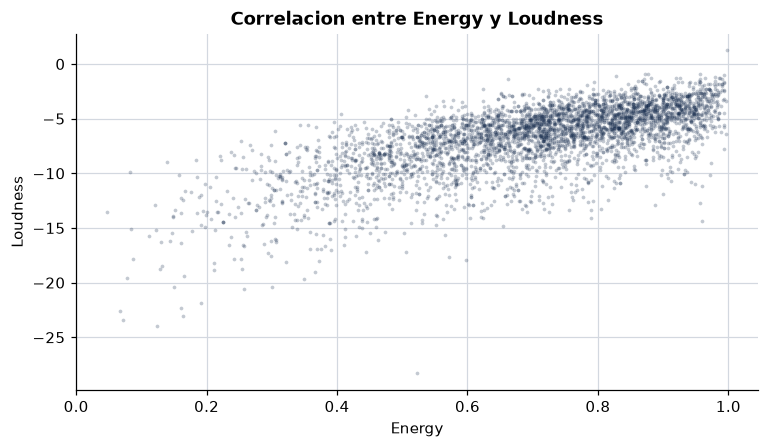

In [5]:
# a) Matriz de correlación
corr = df[audio].corr()
print("a) matriz de correlacion: \n",corr)

# b) Lista de pares ordenada: el más positivo y el más negativo
corr2 = corr.unstack()
corr2 = corr2[corr2 < 0.999]
#print(corr2.index.get_level_values(0))
corr3 = corr2[corr2.index.get_level_values(0) < corr2.index.get_level_values(1) ]
#print('b): \n',corr3.sort_values(ascending=False))
print('\nb) lista de pares ordenada el mas positivo al mas negativo: \n',corr3.sort_values(ascending=False))

# c) Diagrama de dispersión del par más positivo
print('\n c): Diagrama de dispersión del par más positivo:')
m = df.sample(4000, random_state=1)
plt.scatter(m["energy"],m["loudness"],s=6, alpha=0.25,color=AZUL, lw=0)
plt.ylabel('Loudness')
plt.xlabel('Energy')
plt.title('Correlacion entre Energy y Loudness')


# d) Correlación de cada variable de audio con track_popularity
print("\n d) Correlación de cada variable de audio con  track_popularity: ")
df_tp = df[audio + ['track_popularity']].corr()
print(df_tp["track_popularity"].sort_values(ascending=False))

### 📝 Tu respuesta — Ejercicio 4

**1.** ¿Cuál es el par con la correlación **positiva** más fuerte y cuál con la **negativa** más
   fuerte? Da los dos valores de r.

> el par mas positivo mas fuerte es (energy y loudness) r = 0.677, y el mas negativo es (acoustisness  y energy r=(-0.54)) 

**2.** Mira tu diagrama de dispersión. La correlación es alta, pero la nube **no** es una línea.
   ¿Qué te dice eso sobre lo que r puede y no puede predecir para **una** canción concreta?

> entienedo que r nos indica que es una relacion  moderada que entre mas volumen mas energetica es una cancion pero, al vizualizar la grafica no es una linea perfecta por lo que no podemos determinar que una cancion sera mas energetica por subirle el volumen o al inverso.

**3.** Escribe **una frase de veredicto** sobre el par más positivo: ¿se puede afirmar que una
   variable **causa** a la otra? Antes de responder descarta las tres alternativas que vimos en
   clase: una **variable oculta** que mueva a las dos, la **causa invertida**, o la **coincidencia**.

> podria ser  que el genero toma cierto rol como variable oculta, no creo que sea coicidencia, podria ser una causa invertida que al aumentar el volumen aumente la energia, pero no necesariamente una causa a la otra.

**4.** De las 10 variables de audio, ¿cuál correlaciona más con `track_popularity`? ¿Es una
   relación fuerte o débil? ¿Te sirve ese número solo para predecir si una canción será popular?

> la relacion mas fuerte es con acousticness r = 0.08, es una relacion debil, no me funciona para predecir si sera popular.

---
# Ejercicio 5 · La relación escondida
**Dificultad: media** · 25 puntos

En el Ejercicio 4 calculaste correlaciones sobre **toda la tabla**. Pero en el Ejercicio 3
comprobaste que los géneros son muy distintos entre sí. La pregunta final del problem set es qué
pasa cuando juntas las dos cosas.

Trabaja con el par **`energy` y `danceability`**.

**a)** Calcula la correlación entre `energy` y `danceability` **en el conjunto completo**.

**b)** Calcula **esa misma correlación dentro de cada género**. Arma una tabla con los seis
valores, ordenada, y guárdala en `corr_genero`.

**c)** Junta en una sola tabla, para cada género: la **media de energy** (la tienes en
`energia_genero`, del Ejercicio 3), la **media de `danceability`**, la **media de
`track_popularity`** y la **correlación** de (b).

**d)** Estandariza `energy` creando la columna `energy_z`, y encuentra la canción con el
**z más alto**. Muestra su nombre, artista, género, `energy` y `energy_z`.
Comprueba además que `energy_z` tiene media 0 y desviación 1, y que su `skew()` es el mismo
que el de `energy` original.

> 💡 **Pistas.**
> Correlación por grupo:
> `df.groupby("playlist_genre").apply(lambda g: g["energy"].corr(g["danceability"])).sort_values()`
> El `lambda g:` recibe el sub-DataFrame de cada género.
> Para juntar tablas que comparten el mismo índice (el género): `pd.concat([tabla1, tabla2], axis=1)`.
> Estandarización: `z = (x - x.mean()) / x.std()`.
> `.idxmax()` devuelve el **índice** de la fila con el valor máximo; con `df.loc[idx, [...]]`
> sacas las columnas que quieras de esa fila.
>
> ⚠️ Antes de escribir la conclusión, mira los **signos** de la tabla de (b): ¿todos los géneros
> apuntan hacia el mismo lado?

In [6]:
# a) Correlación global entre energy y danceability
corr_genero = corr3[(corr3.index.get_level_values(level=0) == 'danceability') & (corr3.index.get_level_values(level=1) == 'energy') ]
print('a) correlacion energy vs dance: \n',corr_genero)

# b) La misma correlación dentro de cada género
df5 = df[['energy','danceability','playlist_genre']]
datos_5 =  df5.groupby('playlist_genre')[['energy','danceability']].agg('corr')
#df[['energy','danceability','playlist_genre']]
datos_5 = datos_5[datos_5 < 0.999 ] #eliminamos diagonales
datos_5 = datos_5['energy'].dropna() #quitamos vacios
datos_5 = datos_5.droplevel(1) 
print('\n b) correlacion por genero de energy vs dance: \n',datos_5.sort_values(ascending=False)) #correlacion energia y danceabiliy por genero 


energia_mean = energia_genero['mean']
#print('\n promedio de energia:\n',energia_mean.sort_values()) #promedio de energia
dance_mean = df.groupby('playlist_genre')['danceability'].agg('mean')
#print('\n promedio de danceability:\n',dance_mean.sort_values())
track_mean = df.groupby('playlist_genre')['track_popularity'].agg('mean')
#print('\n promedio de track popularity:\n',track_mean)


# c) Tabla resumen por género
resumen =  pd.concat([datos_5,energia_mean,dance_mean,track_mean], axis=1)
resumen = resumen.rename(columns={'energy':'CorEneDance','mean':'PromEne','danceability':'PromDance','track_popularity':'PromTrack'})
print('\n c) tabla resumen: \n',resumen)
#print(resumen.rename(columns='energy',))

# d) Estandarización de energy y canción más extrema
#El energy_z nos dice cuántas desviaciones estándar está un valor por encima o por debajo de la media.
df["energy_z"] = (df["energy"] - df["energy"].mean()) / df["energy"].std()

idx = df["energy_z"].idxmax()
print('\n idx:  \n',idx)

#print(df.columns)
#que tan lejos esta un dato de la media medido en desviaciones estandar.

print("\nd) Estandarización de energy y canción más extrema")
print(df.loc[idx,["track_name","track_artist","playlist_name","energy","energy_z"]])



a) correlacion energy vs dance: 
 danceability  energy   -0.086073
dtype: float64

 b) correlacion por genero de energy vs dance: 
 playlist_genre
r&b      0.159201
latin    0.115939
pop     -0.030729
rap     -0.148173
edm     -0.150262
rock    -0.152882
Name: energy, dtype: float64

 c) tabla resumen: 
                 CorEneDance   PromEne  PromDance  PromTrack
playlist_genre                                             
edm               -0.150262  0.802476   0.655041  34.833526
latin              0.115939  0.708312   0.713287  47.026576
pop               -0.030729  0.701028   0.639302  47.744870
r&b                0.159201  0.590934   0.670179  41.223532
rap               -0.148173  0.650708   0.718353  43.215454
rock              -0.152882  0.732813   0.520548  41.728338

 idx:  
 17004

d) Estandarización de energy y canción más extrema
track_name       Rain Forest and Tropical Beach Sound
track_artist               Nature Sounds Nature Music
playlist_name                         

### 📝 Tu respuesta — Ejercicio 5

**1.** ¿Cuánto vale r en el conjunto completo? ¿Cuál es el género con el r **más negativo** y
   cuál con el **más positivo**? Da los tres números.

> para el valor de R  = -0.086073 (energy con danceability) en el conjunto completo, el genero mas negativos es ROCK con -0.152882 y el mas positivo es r&b con 0.159201  

**2.** Si el r global es cercano a cero, ¿se puede concluir que `energy` y `danceability`
   no tienen ninguna relación? Explica qué está pasando por debajo del promedio global.
   ¿Cuál es la "tercera variable" de la que hablamos en la lámina de correlación y causalidad?

> al correlacionar energy y danceability de manera global notamos una relacion muy debil pero no podria decir que la relacion es nula, hasta que agrupamos por los generos musicales que notamos un aumento significativo algunas mas positivas que otras, no se puede destacar que es debil pero se nota que algunos generos afectan a estas dos variables unas poco mas que otras. en este caso puedo ver que rock y rap estan mas relacionadas con la energia y danceability que pop y latin. pero yo no puedo bailar rock y rap en cambio si se puede bailar pop y latin mucho mas, esto podria ser.
porque las canciones rock y rap sean mas energicas.(como tercera variable el genero musical.)   

**3.** Mira la tabla de (c) junto con lo que sacaste en el Ejercicio 4(d). ¿El género con la
   energía media más alta es también el más popular? ¿Qué le dirías a la plataforma de streaming
   si te pidiera "subirle la energía a las canciones para que sean más populares"?

>El genero con la energia media mas alta no es el mas popular ni si quiera se encuentra dentro de los primeros populares, yo le diria a la plataforma que aumentarle la energia no ayudaria a que las canciones sean mas populares, mas bien si quieren aumentar su popularidad podrian aumentar los acusticos de las canciones o bailabilidad, ya que en la tabla 4 (d) vemos que estas variables tienden a tener cierto aumento en su popularidad.

**4.** La canción con el `energy_z` más alto: ¿qué tan lejos de la media está, en desviaciones
   estándar? ¿Por qué el `skew()` de `energy_z` es idéntico al de `energy`, si le restamos la
   media y la dividimos entre la desviación?

>La cancion con el energy_z mas alto esta a 1.6659 de media en desviacion estandar, por que  al final se realizo una estandarizacion que en relacion al monto incial solo cambio el numero pero no la proporcion con respecto a los datos por eso el skew nos da igual.

---
# Cierre · El entregable escrito

Escribe **un párrafo de 4 a 6 frases** dirigido a alguien que **no tomó este curso** —el gerente
de producto de la plataforma de streaming— con el hallazgo principal del problem set.

Requisitos:

1. Empieza por el **hallazgo**, no por el método.
2. Usa **al menos tres números** de los que calculaste, indicando de qué ejercicio salen.
3. **Sin jerga**: nada de "r", "desviación estándar" ni "skew" sin traducir a español común.
4. Cierra con **una advertencia**: algo que estos datos **NO** permiten concluir.

> 💡 "r = 0.06" no es una frase. "En el conjunto completo parece que no hay relación, pero es
> porque dos géneros se comportan al revés y se cancelan entre sí" sí lo es.

### 📝 Tu párrafo

> Como resumen de los primeros hallazgos encontrados en el dataset se logro observar una poca variabilidad entre generos para sus cantidades lo que ayuda a que el estudio del dataset sea mas eficiente, con el dataset con algunos pocos sesgos con datos vacios y  problemas de captura como canciones con 4 segundos, todo esto obtenidos del ejercicio 1.

Se pudo determinar que se tienen valores mas bajos de energia generalmente y con poca dispersion entre sus generos pero destancando edm (datos obtenidos del ejericicio 2).

Para el genero ROCK notamos una variacion considerable entre sus energias entendiendo que es un genero que no tiene una energia estable segun el dataset, por lo contrario edm con una varianza mas chica y un promedio de energia mas alto ose que son datos que estan mas agrupados energeticamente indicando que contienen un alto grado de energia general.( datos obtenidos en el ejercicio 3 y 4)

la relacion de la energia y loudness determianmos el volumen y la energia se afectan entre ellos, quiza porque el volumen da sensacion que una cancion es mas energetica pero con una alta posibilidad de que el genero influya en esta relacion.

Por otro lado una cancion acustica  presenta menos energia por que no tiene tantos instrumentos y se considera mas la voz del artista.
Tambien se presenta que las canciones mas acusticas son las mas populares (r = 0.085 ej. 5) de todo el dataset , seguido de la musica bailable.

Notamos que el genero toma un papel muy importante entre las canciones mas energeticas y bailables.
Destacando que el R&B (r = 0.159 ej.5)  al aumnetar su bailabilidad aumenta su energia, con el caso contrario sucede rock (r = -0.152 ej.5) que aumenta su energia y disminuye su bailabilidad.
Aumentar los acusticos ayudaria a que tengan un aumneto en la popularidad en ves de aumentar la energia de las canciones.(datos obtenidos de los ejercicios 4 y 5.)




---

### 🤖 Uso de IA

¿En qué ejercicios usaste IA? Para cada uno, explica **qué hace ese código** o **qué alternativa
pensaste antes de preguntar**.

> la IA la utilice principalmente para colocar los datos encima de la grafica de boxplot en donde i obtiene la posicion y valor  y que me ayude a entender los datos que estoy obteniendo en cada ejercicio como interpretarlos.


---

### ✅ Antes de entregar, verifica:

- [ ] Kernel → Restart & Run All: el cuaderno corre de principio a fin **sin errores**.
- [ ] Todos los gráficos tienen **título** y **etiquetas de eje con unidad**.
- [ ] Todas las celdas de *Tu respuesta* están contestadas.
- [ ] El cuaderno está en **GitHub** con el nombre `S100_PS1_TuApellido.ipynb`.
- [ ] Envié el **enlace** (y solo el enlace) a gabriel.soto@utp.ac.pa.
- [ ] Agregué el enlace en `S100 Lista Estudiantes Provisional`, carpeta `01_administracion`
      del SharePoint, junto a mi nombre.